# Notebook 4: Evaluation of BERT and the LLM

This notebook scores the stored repairs of the three methods and compares them:

- **BERT (fine-tuned)**: `bert-base-cased` fine-tuned on clean text, filling the slots left to right with a
  letter-similarity reranking (notebook 2);
- **few-shot**: Llama 3.1 8B Instruct with the instruction, 3 solved examples and the sentence (notebook 3);
- **few-shot + article**: the same with the whole article as context (notebook 3). Only compared with the
  LLM's own few-shot result: BERT sees the sentence only, so this variant is not part of the BERT
  comparison.

BERT and few-shot get exactly the same input (the slot view) and are scored on exactly the same rows. The
damaged text itself ("no repair") is scored the same way as a reference.

**Input.** `data/processed/corrupted_v2.jsonl` (hash checked), the stored predictions in `runs/preds/`
(nothing is sent to a model here), `configs/llm.yaml` for the few-shot examples.

**Output.** The tables and the figure below.

`SPLIT` chooses the rows. It is `dev` here, where the numbers are used to choose settings and are not the
result of the study. A variant is scored only when all of its rows for the split are stored.

In [1]:
import hashlib
import json
import time

import pandas as pd
import transformers
from bert_score import BERTScorer
from rapidfuzz.distance import Levenshtein

from blnrepair.data import ROOT, load_config
from blnrepair.freeze import load_frozen
from blnrepair.bert_repair import load_repair_config, repair_version
from blnrepair.llm import load_llm_config, variant_versions
from blnrepair.plots import level_lines
from blnrepair.preds import load_preds, pred_path, slot_exact
from blnrepair.slots import build_slots, slot_core, slot_view, splice

transformers.logging.set_verbosity_error()
pd.set_option("display.max_colwidth", None)
config, llm_config = load_config(), load_llm_config()
rows = load_frozen("v2")  # stops if the file hash does not match runs/corrupted_v2.sha256
by_key = {(r["id"], r["severity"]): r for r in rows}
LEVELS = ["1w", "10", "25", "50", "75"]
SPLIT = "dev"

D:\UR_Lectures\GenAI_proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. What is scored

The rows are every row of the split that has slots (level 0 is the clean sentence), without the 3
sentences shown as few-shot examples: their gold answers are in the prompt. On the test split this leaves
nothing out, because the examples are dev sentences and dev and test share no excerpt. Below, how many rows
each method has stored.

In [2]:
example_ids = {i for i, _ in llm_config["fewshot_picks"]}
scored_rows = [r for r in rows if r["split"] == SPLIT and r["id"] not in example_ids and r["k"]]
scored_ids = sorted({r["id"] for r in scored_rows})
expected = {(r["id"], r["severity"]) for r in scored_rows}

versions = variant_versions(llm_config, SPLIT)
VARIANTS = {"BERT (fine-tuned)": ("bert_rerank", repair_version(load_repair_config(), SPLIT)),  # written by notebook 2
            "few-shot": versions["few-shot"], "few-shot + article": versions["few-shot + article"]}
ORDER = list(VARIANTS)  # fixed order: a method keeps its colour in every figure
stored = {name: {(p["id"], p["severity"]): p for p in load_preds(pred_path(*v))} for name, v in VARIANTS.items()}
available = [name for name in VARIANTS if expected <= set(stored[name])]
METHODS = available + ["no repair"]
print(f"{len(scored_ids)} sentences, {len(expected)} rows per method in the {SPLIT} split")
pd.DataFrame({"rows stored": {n: len(expected & set(s)) for n, s in stored.items()},
              "rows needed": len(expected), "scored": {n: n in available for n in stored}})

17 sentences, 85 rows per method in the dev split


,rows stored,rows needed,scored
BERT (fine-tuned),85,85,True
few-shot,85,85,True
few-shot + article,85,85,True


## 2. The scores

All scores are per sentence and level, over the damaged span unless stated (dossier §8):

- **BERTScore of the span** (primary): F1 between the repaired span and the gold span, with `roberta-large`
  and the package's baseline rescaling (so unrelated text scores near 0 and identical text 1).
- **Fact Recovery Rate** (primary): share of the span's fact tokens restored exactly in their slot
  (punctuation around the word ignored).
- **Exact words**: share of slots restored exactly.
- **CER before / after and repair gain**: character error rate of the span against the gold span, for
  the damaged text and for the repair; gain = before minus after (positive = the repair helped).
- **BERTScore of the sentence** (secondary): the same for the whole sentence.

A format failure (the LLM answered with the wrong number of words) is scored as **no repair**: its slots
count as wrong, and its text is the damaged text.

In [3]:
def span_row(row):
    # the row cut to its damaged span, so that splice builds the span text only
    s, e = row["span_start"], row["span_end"]
    return {"gold_tokens": row["gold_tokens"][s:e], "ops_per_word": [{**p, "idx": p["idx"] - s} for p in row["ops_per_word"]]}


def row_scores(row, pred_words):
    plans = sorted(row["ops_per_word"], key=lambda p: p["idx"])
    ok = pred_words is not None
    words = pred_words if ok else [p["out"] for p in plans]
    gold_span = " ".join(row["gold_tokens"][row["span_start"]:row["span_end"]])
    damaged_span, repaired_span = splice(span_row(row), [p["out"] for p in plans]), splice(span_row(row), words)
    facts = [slot_core(w) == slot_core(p["gold"]) for w, p in zip(words, plans) if p["idx"] in row["fact_idx_in_span"]]
    cer = lambda text: Levenshtein.distance(text, gold_span) / len(gold_span)
    return {"format_ok": ok, "gold span": gold_span, "damaged span": damaged_span, "repaired span": repaired_span,
            "repaired sentence": splice(row, words), "exact": slot_exact(pred_words, row),
            "fact recovery": sum(facts) / len(facts) if ok else 0.0,
            "CER before": cer(damaged_span), "CER after": cer(repaired_span)}


def multiword_count(p):
    # LLM rows keep a dict with the positions of multi-word answers; BERT rows keep a list of candidates
    raw = json.loads(p["raw_output"])
    return len(raw["multiword"]) if isinstance(raw, dict) else 0


records = []
for name in available:
    for key in sorted(expected):
        p, row = stored[name][key], by_key[key]
        records.append({"method": name, "id": key[0], "level": key[1], "band": row["band"],
                        "multiword": multiword_count(p),
                        **row_scores(row, p["pred_words"])})
for key in sorted(expected):
    records.append({"method": "no repair", "id": key[0], "level": key[1], "band": by_key[key]["band"],
                    "multiword": 0, **row_scores(by_key[key], None), "format_ok": True})
scores = pd.DataFrame(records)
scores["repair gain"] = scores["CER before"] - scores["CER after"]
scores["format failure"] = ~scores["format_ok"]

In [4]:
scorer = BERTScorer(model_type="roberta-large", lang="en", rescale_with_baseline=True)
t0 = time.perf_counter()
scores["BERTScore span"] = scorer.score(list(scores["repaired span"]), list(scores["gold span"]))[2].numpy()
gold_sentence = {r["id"]: r["gold_text"] for r in scored_rows}
scores["BERTScore sentence"] = scorer.score(list(scores["repaired sentence"]), [gold_sentence[i] for i in scores["id"]])[2].numpy()
print(f"BERTScore for {len(scores)} spans and sentences in {time.perf_counter() - t0:.0f} s")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   3%|▎         | 10/389 [00:00<00:04, 90.09it/s]

Loading weights:   5%|▌         | 20/389 [00:00<00:09, 39.64it/s]

Loading weights:   7%|▋         | 26/389 [00:00<00:14, 24.65it/s]

Loading weights:   8%|▊         | 30/389 [00:01<00:18, 19.68it/s]

...

Loading weights:  12%|█▏        | 45/389 [00:03<00:53,  6.39it/s]

Loading weights:  49%|████▊     | 189/389 [00:03<00:01, 175.20it/s]

Loading weights: 100%|██████████| 389/389 [00:03<00:00, 110.92it/s]

D:\UR_Lectures\GenAI_proj\.venv\Lib\site-packages\bert_score\scorer.py:139: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self._baseline_vals = torch.from_numpy(


BERTScore for 340 spans and sentences in 263 s


## 3. Results

Means per method and level:

In [5]:
columns = ["BERTScore span", "fact recovery", "exact", "CER before", "CER after", "repair gain", "BERTScore sentence"]
means = scores.groupby(["method", "level"])[columns].mean().reindex(pd.MultiIndex.from_product([METHODS, LEVELS]))
means.round(3)

BERTScore span  fact recovery  exact  CER before  \
BERT (fine-tuned)  1w           0.528          0.059  0.059       0.290   
                   10           0.311          0.015  0.280       0.334   
                   25           0.093          0.015  0.167       0.311   
                   50           0.063          0.015  0.142       0.306   
                   75          -0.011          0.000  0.110       0.305   
few-shot           1w           0.729          0.412  0.412       0.290   
                   10           0.458          0.250  0.358       0.334   
                   25           0.284          0.216  0.342       0.311   
                   50           0.046          0.132  0.167       0.306   
                   75          -0.104          0.074  0.145       0.305   
few-shot + article 1w           0.698          0.353  0.353       0.290   
                   10           0.510          0.338  0.411       0.334   
                   25           0.262          0.186  0.243       0.311   
                   50           0.040          0.240  0.205       0.306   
                   75          -0.207          0.069  0.038       0.305   
no repair          1w           0.365          0.000  0.000       0.290   
                   10           0.014          0.000  0.000       0.334   
                   25          -0.161          0.000  0.000       0.311   
                   50          -0.266          0.000  0.000       0.306   
                   75          -0.339          0.000  0.000       0.305   

                       CER after  repair gain  BERTScore sentence  
BERT (fine-tuned)  1w      1.022       -0.733               0.948  
                   10      0.724       -0.391               0.882  
                   25      0.702       -0.392               0.676  
                   50      0.725       -0.419               0.422  
                   75      0.742       -0.437               0.201  
few-shot           1w      0.448       -0.158               0.967  
                   10      0.439       -0.105               0.882  
                   25      0.347       -0.037               0.734  
                   50      0.335       -0.029               0.409  
                   75      0.299        0.006               0.104  
few-shot + article 1w      0.660       -0.370               0.967  
                   10      0.381       -0.047               0.890  
                   25      0.404       -0.093               0.719  
                   50      0.331       -0.025               0.406  
                   75      0.358       -0.053               0.013  
no repair          1w      0.290        0.000               0.918  
                   10      0.334        0.000               0.785  
                   25      0.311        0.000               0.512  
                   50      0.306        0.000               0.191  
                   75      0.305        0.000              -0.096

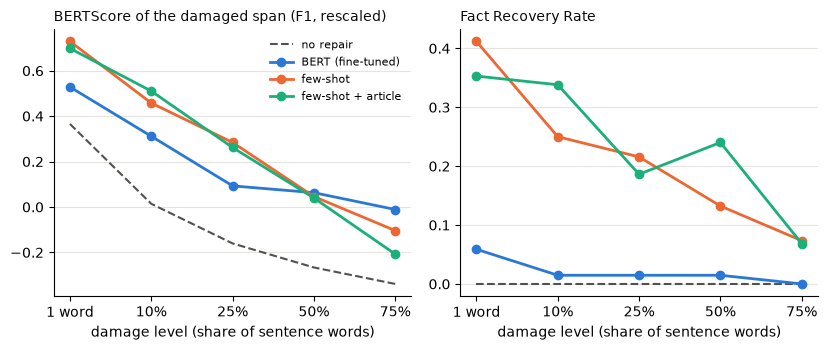

In [6]:
fig = level_lines(means, ["BERTScore span", "fact recovery"],
                  ["BERTScore of the damaged span (F1, rescaled)", "Fact Recovery Rate"], ORDER)

Format failures and multi-word answers per method (a format failure is scored as no repair), and the mean
over all levels:

In [7]:
scores[scores["method"] != "no repair"].groupby("method", sort=False).agg(
    rows=("exact", "size"), format_failures=("format failure", "sum"), multiword=("multiword", "sum"),
    **{c: (c, "mean") for c in ["BERTScore span", "fact recovery", "exact", "repair gain"]}).round(3)

,rows,format_failures,multiword,BERTScore span,fact recovery,exact,repair gain
method,,,,,,,
BERT (fine-tuned),85,0,0,0.197,0.021,0.152,-0.474
few-shot,85,18,0,0.282,0.217,0.285,-0.065
few-shot + article,85,23,0,0.261,0.237,0.250,-0.118


By level and length band (BERTScore of the span, mean): separates the share of damaged words from the
absolute length of the damaged span.

In [8]:
scores.pivot_table(index=["method", "level"], columns="band", values="BERTScore span", aggfunc="mean") \
      .reindex(pd.MultiIndex.from_product([METHODS, LEVELS])).round(3)

band                   20-29  30-44  45-60
BERT (fine-tuned)  1w  0.494  0.687  0.236
                   10  0.450  0.245  0.143
                   25  0.084  0.066  0.176
                   50  0.080  0.057  0.038
                   75  0.032 -0.049 -0.023
few-shot           1w  0.740  0.809  0.514
                   10  0.626  0.314  0.400
                   25  0.301  0.309  0.185
                   50  0.103  0.146 -0.322
                   75 -0.126  0.045 -0.399
few-shot + article 1w  0.751  0.770  0.408
                   10  0.657  0.483  0.231
                   25  0.264  0.321  0.121
                   50  0.255 -0.109 -0.117
                   75 -0.186 -0.147 -0.399
no repair          1w  0.254  0.490  0.335
                   10  0.071 -0.020 -0.040
                   25 -0.098 -0.181 -0.259
                   50 -0.238 -0.271 -0.322
                   75 -0.293 -0.358 -0.399

### Paired comparisons

Every sentence is repaired at every level by every method, so the methods are compared sentence by
sentence: the mean difference (first minus second) and how many sentences were better, equal or worse.
**BERT against few-shot** is the main comparison; both get the same sentence-only input. **Few-shot +
article against few-shot** shows whether the article helps the LLM; it is not a BERT comparison.

In [9]:
def paired(a, b, metric):
    wide = scores[scores["method"].isin([a, b])].pivot_table(index=["level", "id"], columns="method", values=metric)
    diff = (wide[a] - wide[b]).rename("diff").reset_index()
    return diff.groupby("level").agg(mean_diff=("diff", "mean"), better=("diff", lambda d: (d > 1e-9).sum()),
                                     same=("diff", lambda d: (d.abs() <= 1e-9).sum()),
                                     worse=("diff", lambda d: (d < -1e-9).sum())).reindex(LEVELS)


def paired_table(a, b):
    if {a, b} - set(available):
        print(f"{a} against {b}: not scored yet ({', '.join(sorted({a, b} - set(available)))} has no complete run)")
        return None
    return pd.concat({m: paired(a, b, m) for m in ["BERTScore span", "fact recovery"]}, axis=1).round(3)


for a, b in [("BERT (fine-tuned)", "few-shot"), ("few-shot + article", "few-shot")]:
    table = paired_table(a, b)
    if table is not None:
        display(table)

BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w            -0.201      4    0    13        -0.353      1    9     7
10            -0.146      4    0    13        -0.235      0   12     5
25            -0.191      5    0    12        -0.201      1    9     7
50             0.017      9    0     8        -0.118      1   12     4
75             0.093     11    0     6        -0.074      0   13     4

BERTScore span                   fact recovery                  
           mean_diff better same worse     mean_diff better same worse
level                                                                 
1w            -0.030      1   12     4        -0.059      0   16     1
10             0.053      8    2     7         0.088      4   10     3
25            -0.022     10    1     6        -0.029      2   12     3
50            -0.006      7    4     6         0.108      6    9     2
75            -0.104      3   10     4        -0.005      2   13     2

### Contamination probe

The share of near-verbatim continuations of the LLM's probe (notebook 3): a high share would mean the LLM
results may be inflated.

In [10]:
probe = pd.DataFrame([json.loads(p["raw_output"]) for p in load_preds(pred_path(*versions["probe"]))])
print(f"probe on {len(probe)} {SPLIT} sentences: {probe['near_verbatim'].sum()} near-verbatim "
      f"({probe['near_verbatim'].mean():.0%}); similarity median {probe['similarity'].median():.2f}, max {probe['similarity'].max():.2f}")

probe on 20 dev sentences: 0 near-verbatim (0%); similarity median 0.24, max 0.60


## 4. Manual check

18 repairs (6 sentences at levels 10, 25 and 50, drawn with the project seed) for reading by hand, to find
repairs that are fluent but wrong.

In [11]:
rank = lambda i: hashlib.sha256(f"{config['seed']}-manual-{i}".encode()).hexdigest()
manual_ids = sorted(scored_ids, key=rank)[:6]
look = scores[scores["id"].isin(manual_ids) & scores["level"].isin(["10", "25", "50"])]
look.pivot_table(index=["id", "level", "gold span", "damaged span"], columns="method", values="repaired span", aggfunc="first") \
    [available].reset_index().drop(columns="id")

method,level,gold span,damaged span,BERT (fine-tuned),few-shot,few-shot + article
0,10,"No. 12, Market-place, Oxford-street, on","Uo. NIaruet-plece, Oforcl-sbteet, an","No. 5 Souths-place, Tottenham-square, on","No. Nairne-place Oxford-street, as, as","No. Norwich Norwich, on, and"
1,25,"occupier of a house, No. 12, Market-place, Oxford-street, on the site of the","ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af","landlord of a house, No. 9 Souths-place, Tottenham-square, and was included in the","occupier of the house, Uttle. Nairn-place Offley-street, and, the site of an old","occupier of the house, in. Urbane Place, Offcl-street, and the site of old"
2,50,"years past the prisoner was the occupier of a house, No. 12, Market-place, Oxford-street, on the site of the old Oxford-street Market, and complaints were","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","time past he had been ininging a very bad habit, Mr. John Pn-Pnl, an-architect, was called to speaksp a very seriousquiries-the usualroner, and thatquiriesquiries were","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte","vears pasb bhe prlsoser wes tho ocoupie ot honse, Uo. NIaruet-plece, Oforcl-sbteet, an tbe sIte af Olford-gtrect Msrkt, conpiainte"
3,10,"mother, Ellen Bean.","mather, Elen Besn.","master, William Burl.","mother, Eleanor Benson.","mother, Eleanor Beeman."
4,25,"bank notes from his mother, Ellen Bean.","bana trom hi mather, Elen Besn.","a publichouse at the Whiteston, White Hart.","banana ? from his mother, Eleanor Benson.","bank of from his mother, Elizabeth Bennett."
5,50,"tried and convicted of stealing £140 in bank notes from his mother, Ellen Bean.","trled ald ef stoalinb £l40 ii bana trom hi mather, Elen Besn.","charged with havingelonio andnionio and £2 10s forsnio andnionio andnionio andnionio andnionio, a youngman.","trled ald ef stoalinb £l40 ii bana trom hi mather, Elen Besn.","tried alleged of stealing £140 £in bank from his mother Eleanor Benson, from him."
6,10,"bicycle for £2, and","icyclc tor £1, aud","sum of £1s, and","bicycle to £10, and","icycle to £10, and"
7,25,"sold the bicycle for £2, and then came to","so1d tbe icyclc tor £1, aud bhen eame bo","had been finedly fined £1s, and had beend to","sold the icycler tour £1, and then came to","sold the icycle for £and, then came to the"
8,50,"where, it was asserted, he sold the bicycle for £2, and then came to London with the money.","It wae assetod, e so1d tbe icyclc tor £1, aud bhen eame bo Loidou witb tbe nioney.","where he was employed, and had beend fined about £10s, and he was fined about 2 lbs ofs.","to it was assessed, so the cycle for and £then, he Lord with the union and with the.","It wae assetod, e so1d tbe icyclc tor £1, aud bhen eame bo Loidou witb tbe nioney."
9,10,"238 D, in","23B T, ii","Cool andalll, in","Twenty-Three To, Two","23rd Thomas, two"
